In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [4]:
# Load Dataset
df = pd.read_csv(
    r"C:\Users\hawra\Desktop\Absenteeism at work An UCI dataset\Absenteeism_at_work.csv"
)

print("Dataset Shape:", df.shape)


Dataset Shape: (740, 21)


In [25]:
# Task 1: Data Quality Issues

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)


Missing Values:
ID                                 0
Reason for absence                 0
Month of absence                   0
Day of the week                    0
Seasons                            0
Transportation expense             0
Distance from Residence to Work    0
Service time                       0
Age                                0
Work load Average/day              0
Hit target                         0
Disciplinary failure               0
Education                          0
Son                                0
Social drinker                     0
Social smoker                      0
Pet                                0
Weight                             0
Height                             0
Body mass index                    0
Absenteeism time in hours          0
dtype: int64

Duplicate Rows:
34

Data Types:
ID                                   int64
Reason for absence                   int64
Month of absence                     int64
Day of the week                

The dataset has 740 rows and 21 columns. There were no missing values, however there were 34 duplicate rows. Numerical features are also included, represented as integers and floating points.

In [8]:
# Task 2: Missing Value Strategy


# Create artificial missing values
df_missing = df.copy()

df_missing.loc[0:4, 'Age'] = np.nan

print("\nMissing Values Before Handling:")
print(df_missing['Age'].isnull().sum())

# Mean Imputation
df_missing['Age'] = df_missing['Age'].fillna(
    df_missing['Age'].mean()
)

print("\nMissing Values After Handling:")
print(df_missing['Age'].isnull().sum())



Missing Values Before Handling:
5

Missing Values After Handling:
0


The original dataset was complete without any missing value. To illustrate missing value treatment, a total of five missing values are introduced into the Age column and are imputed.

In [17]:
# Task 3: Detect and Handle Outliers Using IQR


Q1 = df['Absenteeism time in hours'].quantile(0.25)
Q3 = df['Absenteeism time in hours'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Absenteeism time in hours'] < lower) |
    (df['Absenteeism time in hours'] > upper)
]

print("Number of outliers:", outliers.shape[0])

# Handle Outliers using IQR

df_clean = df.copy()

numeric_cols = [
    'Distance from Residence to Work',
    'Age',
    'Work load Average/day ',
    'Absenteeism time in hours'
]

for col in numeric_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]

print("Shape before removing outliers:", df.shape)
print("Shape after removing outliers:", df_clean.shape)

Number of outliers: 44
Shape before removing outliers: (740, 21)
Shape after removing outliers: (662, 21)


Outliers were identified by applying the IQR technique and subsequent removing from some numerical features. The size of the data set was reduced by discarding the outlier.

In [18]:
# Task 4A: Min-Max Normalization

from sklearn.preprocessing import MinMaxScaler

minmax_df = df_clean.copy()

minmax_scaler = MinMaxScaler()

minmax_df[numeric_cols] = minmax_scaler.fit_transform(
    minmax_df[numeric_cols]
)

print("Min-Max Normalization:")
print(minmax_df[numeric_cols].head())

Min-Max Normalization:
   Distance from Residence to Work       Age  Work load Average/day   \
0                         0.659574  0.230769                0.244925   
1                         0.170213  0.884615                0.244925   
2                         0.978723  0.423077                0.244925   
3                         0.000000  0.461538                0.244925   
4                         0.659574  0.230769                0.244925   

   Absenteeism time in hours  
0                      0.250  
1                      0.000  
2                      0.125  
3                      0.250  
4                      0.125  


Numerical values are Min-Max normalized to a scale of 0 to 1.

In [21]:
# Task 4B: Z-Score Standardization

from sklearn.preprocessing import StandardScaler

zscore_df = df_clean.copy()

zscore_scaler = StandardScaler()

zscore_df[numeric_cols] = zscore_scaler.fit_transform(
    zscore_df[numeric_cols]
)

print("Z-Score Standardization:")
print(zscore_df[numeric_cols].head())

Z-Score Standardization:
   Distance from Residence to Work       Age  Work load Average/day   \
0                         0.407282 -0.514836               -0.831678   
1                        -1.150437  2.276089               -0.831678   
2                         1.423186  0.306025               -0.831678   
3                        -1.692253  0.470197               -0.831678   
4                         0.407282 -0.514836               -0.831678   

   Absenteeism time in hours  
0                  -0.079391  
1                  -1.247321  
2                  -0.663356  
3                  -0.079391  
4                  -0.663356  


Z-score standardization converts characteristics to be zero-mean unit-variance.

Explained Variance Ratio:
[0.29066639 0.2790168  0.23098109 0.19933572]

Cumulative Explained Variance:
[0.29066639 0.56968318 0.80066428 1.        ]


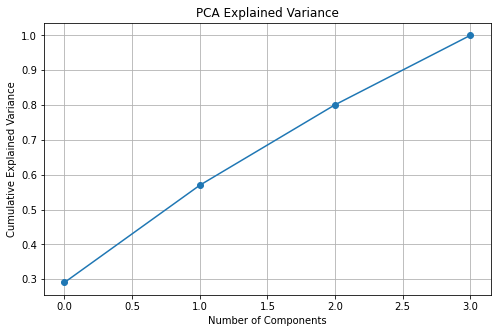

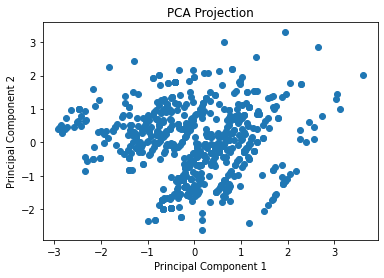

In [24]:
# Task 5: PCA

from sklearn.decomposition import PCA

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    df_clean[numeric_cols]
)

pca = PCA()

pca_result = pca.fit_transform(
    scaled_data
)

explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(explained_variance)

print("\nCumulative Explained Variance:")
print(np.cumsum(explained_variance))

plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(explained_variance),
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)

plt.show()

plt.figure(figsize=(6,4))

plt.scatter(
    pca_result[:,0],
    pca_result[:,1]
)

plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

The first principal component accounts for around 29.1% of the variance and the second about 27.9%. Cumulatively, the first two components explain around 57% of the total variance.